# Notebook 9 – Classification Threshold Optimization

**Dataset:** Online Retail transactions (`data.csv`)

**Task:** Predict whether an order is from the **United Kingdom** or not, using `Quantity`, `UnitPrice`, `TotalPrice`.

## Setup: Load, Split, Train

In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
df = pd.read_csv('data.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].sample(3000, random_state=42)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
X = df[['Quantity', 'UnitPrice', 'TotalPrice']]
y = (df['Country'] == 'United Kingdom').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

## 1. Classification Probability
Most classifiers don't just output a class — they output a **probability** (0 to 1) of belonging to the positive class. The final label comes from comparing this probability to a threshold.

In [2]:
probs = model.predict_proba(X_test)[:, 1]
print("Example predicted probabilities:", probs[:10])

Example predicted probabilities: [0.89410249 0.89811212 0.90024656 0.89212247 0.88844944 0.89879506
 0.89773224 0.89811212 0.90158302 0.90039883]


## 2. Default Threshold
By default, scikit-learn's `.predict()` uses a threshold of **0.5**: if the predicted probability ≥ 0.5, predict class 1 (UK), otherwise class 0.

In [3]:
default_preds = model.predict(X_test)
manual_preds_05 = (probs >= 0.5).astype(int)
print("Predictions match default .predict():", (default_preds == manual_preds_05).all())

Predictions match default .predict(): True


## 3. Decision Threshold
The **decision threshold** is the cutoff probability used to decide the final class. It doesn't have to be 0.5 — moving it up or down changes which predictions count as positive.

In [4]:
for t in [0.3, 0.5, 0.7]:
    preds = (probs >= t).astype(int)
    print(f"Threshold={t}: predicted positive count = {preds.sum()}")

Threshold=0.3: predicted positive count = 600
Threshold=0.5: predicted positive count = 600
Threshold=0.7: predicted positive count = 599


## 4. Threshold Tuning
Deliberately choosing a threshold (instead of the default 0.5) to better match your goals — e.g., a lower threshold catches more positives (higher recall) but with more false alarms (lower precision).

In [5]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
for t in thresholds:
    preds = (probs >= t).astype(int)
    print(f"t={t}: Precision={precision_score(y_test, preds, zero_division=0):.3f}, "
          f"Recall={recall_score(y_test, preds, zero_division=0):.3f}, "
          f"F1={f1_score(y_test, preds, zero_division=0):.3f}")

t=0.1: Precision=0.897, Recall=1.000, F1=0.946
t=0.3: Precision=0.897, Recall=1.000, F1=0.946
t=0.5: Precision=0.897, Recall=1.000, F1=0.946
t=0.7: Precision=0.896, Recall=0.998, F1=0.945
t=0.9: Precision=0.978, Recall=0.247, F1=0.395


## 5. Precision vs Recall Trade-off
As the threshold rises, the model becomes **stricter** — precision tends to go up (fewer false alarms) but recall tends to go down (more missed positives). Lowering the threshold does the opposite. You can't usually maximize both at once.

In [12]:
%matplotlib inline

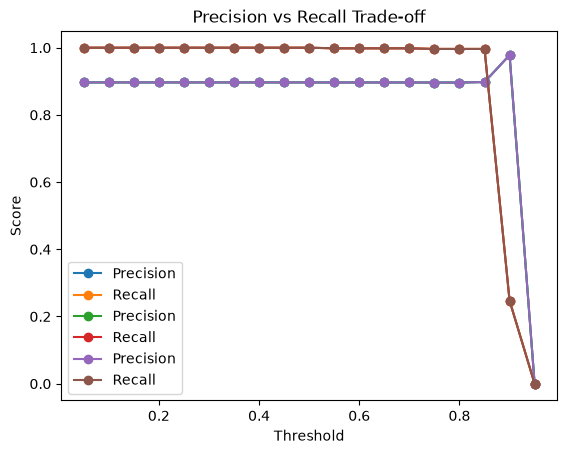

In [13]:
import matplotlib.pyplot as plt
precisions = [precision_score(y_test, (probs >= t).astype(int), zero_division=0) for t in np.linspace(0.05, 0.95, 19)]
recalls = [recall_score(y_test, (probs >= t).astype(int), zero_division=0) for t in np.linspace(0.05, 0.95, 19)]
plt.plot(np.linspace(0.05, 0.95, 19), precisions, marker='o', label='Precision')
plt.plot(np.linspace(0.05, 0.95, 19), recalls, marker='o', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Trade-off')
plt.legend()
plt.show()

## 6. False Positive
A **False Positive** is when the model predicts "UK" but the order is actually from another country. This is a "false alarm".

In [7]:
preds_05 = (probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, preds_05)
tn, fp, fn, tp = cm.ravel()
print("False Positives:", fp)

False Positives: 62


## 7. False Negative
A **False Negative** is when the model predicts "not UK" but the order is actually from the UK. This is a "missed case".

In [8]:
print("False Negatives:", fn)

False Negatives: 0


## 8. Business Cost of Errors
False Positives and False Negatives often have **different real-world costs**. For example, if flagging non-UK orders wrongly (False Positive) causes wasted customs paperwork, but missing a real UK order (False Negative) causes a shipping delay complaint, the two mistakes aren't equally bad — so the "best" threshold depends on which error is more expensive for the business, not just on accuracy.

In [9]:
cost_per_fp = 5    
cost_per_fn = 20   
for t in [0.3, 0.5, 0.7]:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = fp * cost_per_fp + fn * cost_per_fn
    print(f"Threshold={t}: FP={fp}, FN={fn}, Estimated business cost=${total_cost}")

Threshold=0.3: FP=62, FN=0, Estimated business cost=$310
Threshold=0.5: FP=62, FN=0, Estimated business cost=$310
Threshold=0.7: FP=62, FN=1, Estimated business cost=$330


## Confusion Matrix at Different Thresholds
Watch how the confusion matrix shifts as we move the threshold from strict to lenient.

In [10]:
for t in [0.3, 0.5, 0.7]:
    preds = (probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(confusion_matrix(y_test, preds))


Threshold = 0.3
[[  0  62]
 [  0 538]]

Threshold = 0.5
[[  0  62]
 [  0 538]]

Threshold = 0.7
[[  0  62]
 [  1 537]]
